# ASTR-154 Final Project - Exoplanet Obliquity Angle
## File: hypothesis_testing

**Authors:** Babak Aryan, Justin Kan

**Date:** 05/31/2026

**Description:** This file contains the code for our final project in ASTR-154 lab. The project examines the populations of planetary obliquity data of a number of exoplanets from the NASA Exoplanet Database. The populations are divided between host systems with a single star vs. those with more than one star. This notebook is divided into the following subsections:

- Section 1. Hypothesis Testing
  
  In this section, the populations exoplanets with obliquity data from single and non-single host systems are compared to test the hypothesis whether the two populations are the same.

- Section 2. Correlation Testing

  In this section, the correlation between obliquity angle and RUWE (Renormalized Unit Weight Error - an indicator of whether the host system might be a non-single stellar system) is examined for various grouping of the original exoplanet dataset from Section 1.

- Section 3. Clustering (future work)

  We attempt to further investigate whether exoplanets can be clustered into those in single stellar host systems and those in non-single stellar host systems based on various features such as obliquity angle, proper motion, planet's mass, host star's mass and others.

- Section 4. Classification (future work)

  We attempt to further investigate whether exoplanets can be classified into those in single stellar host systems and those in non-single stellar host systems based on various features such as obliquity angle, proper motion, planet's mass, host star's mass and others. The verified number of stars in the host system based on the test statistic RUWE <= 1.4 is used as labels for training the classifier. We would like to know if ystems with RUWE > 1.4 can be then be used as new data to be classified.


### 1. Hypothesis Testing

In this setion, exoplanet data is read in, procerssed and divided into the two sets 1) exoplanets in host systems containing only 1 star and 2) exoplanets in host systems containing more than 1 star. The division is first done purely based on the number of stars listed for each planet in the NASA Exoplanet Archive database. The two groups are then tested to test whether they belong to the same underlying population.

In the second part of this subsection, the grouping of the data is done based on not only the listed number of stars for each planet but also based on the RUWE number for the host star as listed in the GAIA database. RUWE is a statistical indicator of the "multiplicity" of the host system. Using RUWE, the planets whose hosts are listed as a single stellar system are examined to determine whether they indeed might belong to a non-single system. After this re-grouping, the two groups are again tested to see if they belong to the same population.

#### 1.1 Loading and Prepping the Exoplanet Data

In this section, exoplanet data are loaded from a .csv file which had been earlier downloaded from the NASA Exoplanet Archive database. The data, as a minimum, has been filtered and contains the columns listed below:
- Gaia DR2 source ID (`gaia_dr3_source_id`)
- System's Number of Stars (`sy_snum`): 'not null'
- Planet's projected obliquity angle (`pl_projobliq`): 'no null

The dataset is then divided into two sets; one with only a single star and another with more than one star.

In [1]:
# Load required libraries
from IPython.display import display, Math, Markdown, HTML
from astropy import table
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in the Exoplanet data generated from the "NASA Exoplanet Archive" database
#   This particular list conatins only exoplanets whose listed project obliquity value
#   is not null.
data_file_loc = '../data/'
exo_file_name = 'NASA-Exoplanet-Archive-20260514.csv'
exo_table = table.Table.read(data_file_loc+exo_file_name, format='ascii.csv', header_start=123)

In [3]:
# Display the data with the minimum required columns
# (used for inclusion in presentation and report)
exo_table['gaia_dr3_source_id', 'sy_snum', 'pl_projobliq'].to_pandas()


,gaia_dr3_source_id,sy_snum,pl_projobliq
0,6794047652729201024,1,-4.7
1,3105507886130792448,1,77.0
2,4285511294172309504,1,0.1
3,3120058170178779392,1,-10.0
4,3120002649138831360,1,-52.0
...,...,...,...
258,470650560779277952,1,40.2
259,990291507088739072,1,-46.7
260,1114308481603347584,1,-20.7
261,2303332931542914048,1,0.0


In [4]:
# Divide the list into two sets, one containing only exoplanets with a single
# star system ('single_sys'), and the other with 2 or more star systems
# ('binary_sys')
col_keys = ['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
binary_sys = exo_table[exo_table['sy_snum'] >  1][col_keys]
single_sys = exo_table[exo_table['sy_snum'] == 1][col_keys]
# Display a few samples of the data
display(single_sys.to_pandas())
display(binary_sys.to_pandas())

,gaia_dr3_source_id,discoverymethod,sy_snum,pl_projobliq
0,6794047652729201024,Transit,1,-4.7
1,3105507886130792448,Transit,1,77.0
2,4285511294172309504,Transit,1,0.1
3,3120058170178779392,Transit,1,-10.0
4,3120002649138831360,Transit,1,-52.0
...,...,...,...,...
182,470650560779277952,Transit,1,40.2
183,990291507088739072,Transit,1,-46.7
184,1114308481603347584,Transit,1,-20.7
185,2303332931542914048,Transit,1,0.0


,gaia_dr3_source_id,discoverymethod,sy_snum,pl_projobliq
0,4287820848378092672,Transit,2,4.00
1,3393939030531019520,Transit,2,-1.47
2,1928431764627661440,Transit,2,3.70
3,1340497608486742400,Transit,2,189.10
4,381592313648387200,Transit,3,-10.00
...,...,...,...,...
71,2312679845530628096,Transit,2,-143.00
72,3909745223886018432,Transit,2,14.00
73,6077185317188247936,Transit,2,-8.00
74,6780546169634170496,Transit,2,151.00


#### 1.2 Hypothesis Testing I

In this section, the pdf and cdf of the two sets of data are plotted first as a reference. Then K-S and A-D hypothesis testing is perfomed on the two sets to test whether they belong to the same population or not.

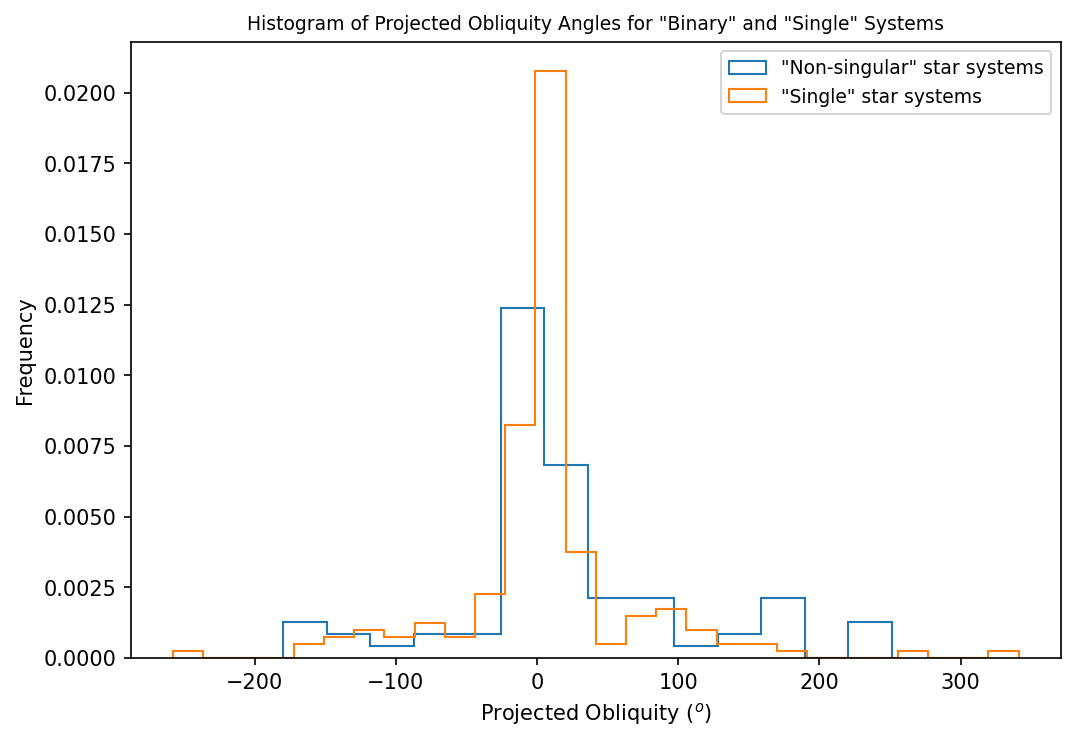

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [60]:
# Plot the PDFs of the two datasets

# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys['pl_projobliq'], histtype='step', bins='auto', density=True);

plt.title('Histogram of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=1);

output_loc = '../results/'
plt.savefig(output_loc + 'obliq_hist_nonRuwe.png', transparent=True, dpi=300, format='png')

plt.show()

# Calculate the mean and standard deviation of the two populations as well
avg_sin_nonRuwe = np.mean(single_sys['pl_projobliq'])
std_sin_nonRuwe = np.std(single_sys['pl_projobliq'])
prmpt = r'\text{For single star systems, mean and standard deviation of projected obliquity angles are: }'
avg_txt = f'{avg_sin_nonRuwe:.3f}'
std_txt = f'{std_sin_nonRuwe:.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

avg_bin_nonRuwe = np.mean(binary_sys['pl_projobliq'])
std_bin_nonRuwe = np.std(binary_sys['pl_projobliq'])
prmpt = r'\text{For binary star systems, mean and standard deviation of projected obliquity angles are: }'
avg_txt = f'{avg_bin_nonRuwe:.3f}'
std_txt = f'{std_bin_nonRuwe:.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));


As seen above, the means and standard deviations of the two datasets are also computed and displayed. These values provide some information about the statistics of the two populations.

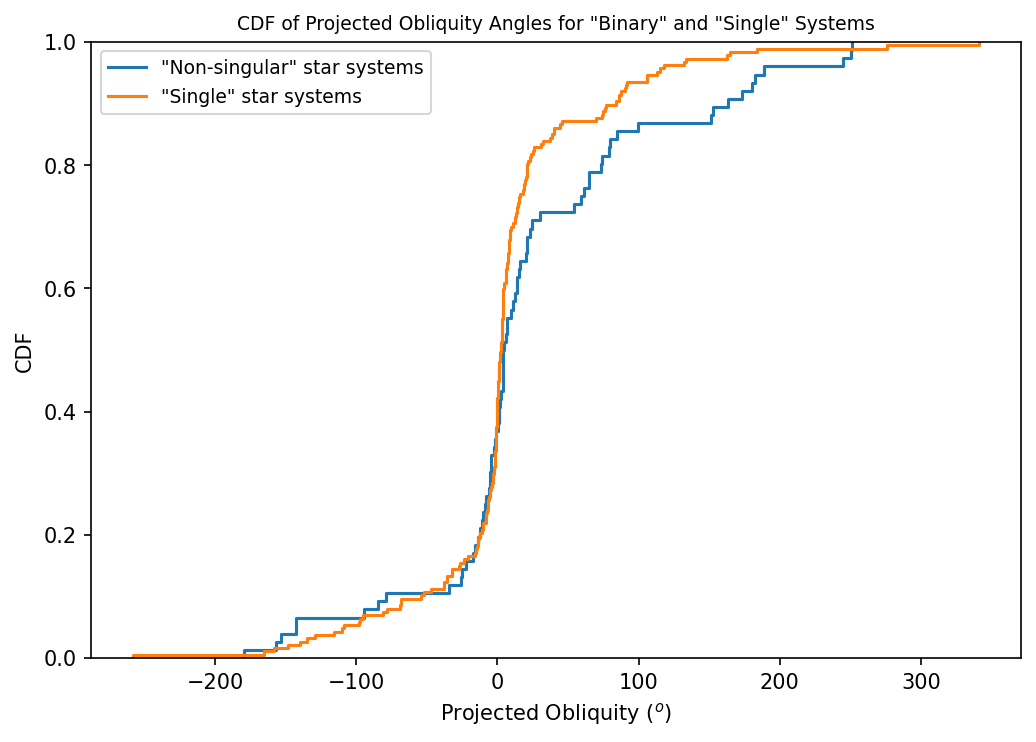

In [55]:
# Plot the CDFs of the two datasets

# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys['pl_projobliq']);
plt.ecdf(single_sys['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=2);

plt.savefig(output_loc + 'obliq_ecdf_nonRuwe.png', transparent=True, dpi=300, format='png')

plt.show()

Performing the actual hypothesis testing below.

In [7]:
from scipy import stats

In [63]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d_nonRuwe, ks_p_nonRuwe = stats.kstest(binary_sys['pl_projobliq'], single_sys['pl_projobliq'])
print(f'K-S D, p-value: {ks_d_nonRuwe:0.4f} {ks_p_nonRuwe:0.4}')

K-S D, p-value: 0.1480 0.1659


In [64]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad_nonRuwe = stats.anderson_ksamp([binary_sys['pl_projobliq'], single_sys['pl_projobliq']], variant='midrank',
                          method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad_nonRuwe.statistic:0.4f} {ad_nonRuwe.pvalue:0.4}')


A-D statistics and p-value: 1.4780 0.083


#### 1.3 Gaia Data Retrieval

To get the RUWE number for the stars associated with the exoplanets in our dataset from NASA Exoplanet Archive, we first ran the following query in the Gaia Archive database. The query extracts all the columns for records whose Gaia DR3 source ID is found in the list of IDs from our dataset from section 1.1. *(Note that the query below lists only a few of the ID numbers.)*

SELECT * 
FROM gaiaedr3.gaia_source 
WHERE source_id IN (6794047652729201024, 3105507886130792448, 4285511294172309504, 3120058170178779392, 3120002649138831360, ... 470650560779277952, 470650560779277952, 990291507088739072, 1114308481603347584, 2303332931542914048, 4623036865373793408)

The query was then saved to a csv file which is loaded into the notebook here.

The newly loaded table from the Gaia dataset will be joined with our original exoplanet dataset from section 1.1 and filtered to create two new sets. This time, the single set contains only systems whose RUWE <= 1.4 providing strong indication that the host system truly contained only a single star. The "binary" set, on the other hand, will contain all the systems with listed number of stars > 1 and also those with listed number of stars = 1 whose RUWE > 1.4 (indicating that the host system is most likely "binary").

In [10]:
# Read in a list of stars from the Gaia database where their Gaia DR3 id
# matches those in our Exoplanet dataset above
data_file_loc = '../data/'
gaia_file_name = 'Gaia-Cross-Ref-20260515.csv'
gaia_table = table.Table.read(data_file_loc+gaia_file_name, format='ascii.csv')

In [11]:
# Display the data with the minimum required columns
# (used for inclusion in presentation and report)
display(gaia_table['source_id', 'ruwe'].to_pandas())

,source_id,ruwe
0,2323985539482908416,1.061217
1,2359978293137038720,33.529186
2,2512326349403275520,4.400844
3,5245968236116294016,0.809564
4,6186950525042445824,1.326742
...,...,...
211,2997312063605005056,0.915554
212,2554032474712538880,0.811488
213,1612165353793791488,0.885308
214,3291455819447952768,0.949175


The data from Gaia was then joined with our dataset from section 1.1. The joined dataset was then filtered to extract exoplanets with single stars whose RUWE > 1.4, indicating that the system probably contains more than 1 star. 

In [12]:
# Extract those stars whose RUWE > 1.4
possible_binary_sys = gaia_table[gaia_table['ruwe'] > 1.4]['designation', 'source_id', 'ruwe']

# Using the ids of the stars in the list above, extract exoplanets listed
# as sinble start systems which could be "possible" binary systems
include_col = ['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq']
possible_binary_sys = table.join(possible_binary_sys, exo_table, keys_left='source_id',
                                 keys_right='gaia_dr3_source_id')[include_col]
possible_binary_sys = possible_binary_sys[possible_binary_sys['sy_snum'] == 1]
display(possible_binary_sys.to_pandas())

,gaia_dr3_source_id,discoverymethod,sy_snum,pl_projobliq
0,2546413408888429696,Transit,1,-2.0
1,3578638842054261248,Transit,1,90.0
2,3578638842054261248,Transit,1,118.1
3,3578638842054261248,Transit,1,-158.0
4,4439085988769170432,Transit,1,3.0
5,4641274773980363520,Transit,1,26.0
6,5065640460769428224,Transit,1,-7.0
7,5086537022856406272,Transit,1,22.0
8,5444147952811517696,Transit,1,-4.0
9,6173451477191225984,Transit,1,162.4


In [13]:
# Modify the two original lists of exoplanets to now include "possible" binary
# systems in the list of exoplanets in "binary" systems:
#   Add the list of items from "possible_binary_sys" to the original
#   "binary_sys" list
binary_sys_ruwe = table.vstack([binary_sys, possible_binary_sys])
binary_sys_ruwe = table.join(gaia_table, binary_sys_ruwe, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum',
                                                              'pl_projobliq', 'ruwe', 'pm']

#   Extract those stars whose RUWE <= 1.4
single_sys_ruwe = gaia_table[gaia_table['ruwe'] <= 1.4]['designation', 'source_id', 'ruwe', 'pm']

#   Using the ids of the stars in the list above, extract the corresponding
#   exoplanet data for "single" star systems
single_sys_ruwe = table.join(single_sys_ruwe, single_sys, keys_left='source_id',
                             keys_right='gaia_dr3_source_id')['gaia_dr3_source_id', 'discoverymethod', 'sy_snum',
                                                              'pl_projobliq', 'ruwe', 'pm']

display((binary_sys_ruwe[binary_sys_ruwe['ruwe'] > 1.4]
                        ['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm']).to_pandas())
display((single_sys_ruwe['gaia_dr3_source_id', 'discoverymethod', 'sy_snum', 'pl_projobliq', 'ruwe', 'pm']).to_pandas())

print(f'Mean RUWE for "binary" star systems: {np.mean(binary_sys_ruwe['ruwe']):.2f}\n')
print(f'Mean RUWE for "single" star systems: {np.mean(single_sys_ruwe['ruwe']):.2f}\n')


,gaia_dr3_source_id,discoverymethod,sy_snum,pl_projobliq,ruwe,pm
0,123376685084303360,Transit,3,7.00,3.598693,44.558315
1,1748596020745038208,Transit,2,-153.00,1.572911,48.817350
2,2126633166627436928,Transit,2,74.00,13.121313,20.477741
3,2359978293137038720,Transit,2,12.70,33.529186,14.801034
4,2512326349403275520,Transit,2,61.28,4.400844,60.998700
5,2512326349403275520,Transit,2,64.60,4.400844,60.998700
6,2546413408888429696,Transit,1,-2.00,1.732632,16.562433
7,3393939030531019520,Transit,2,-1.47,1.475740,13.190645
8,3578638842054261248,Transit,1,90.00,1.539718,97.118290
9,3578638842054261248,Transit,1,118.10,1.539718,97.118290


,gaia_dr3_source_id,discoverymethod,sy_snum,pl_projobliq,ruwe,pm
0,114340658009875072,Transit,1,1.41,1.037848,64.626600
1,179498266829041664,Transit,1,13.00,0.925390,17.060750
2,181908842994567936,Transit,1,2.70,0.991973,50.714485
3,430269136520563200,Transit,1,-14.40,0.854433,3.885188
4,457317534880081152,Transit,1,6.90,0.951508,3.371222
...,...,...,...,...,...,...
172,6794047652729201024,Transit,1,-4.70,0.927357,456.997560
173,6805149288493408640,Transit,1,76.00,0.981307,9.941945
174,6805886373600546176,Transit,1,3.00,1.051834,18.643608
175,6910753016653587840,Transit,1,0.40,0.993029,99.490150


Mean RUWE for "binary" star systems: 1.78

Mean RUWE for "single" star systems: 1.01



Note that the mean of the RUWE number for the new "binary" set is 1.78, and the one for the new single set is 1.01.

#### 1.4 Hypothesis Testing II

In this section, the pdf and cdf of the two new sets are plotted again for a comparison with the first set. Then K-S and A-D hypothesis testing is then perfomed on the two sets to test whether these two new sets belong to the same population or not.

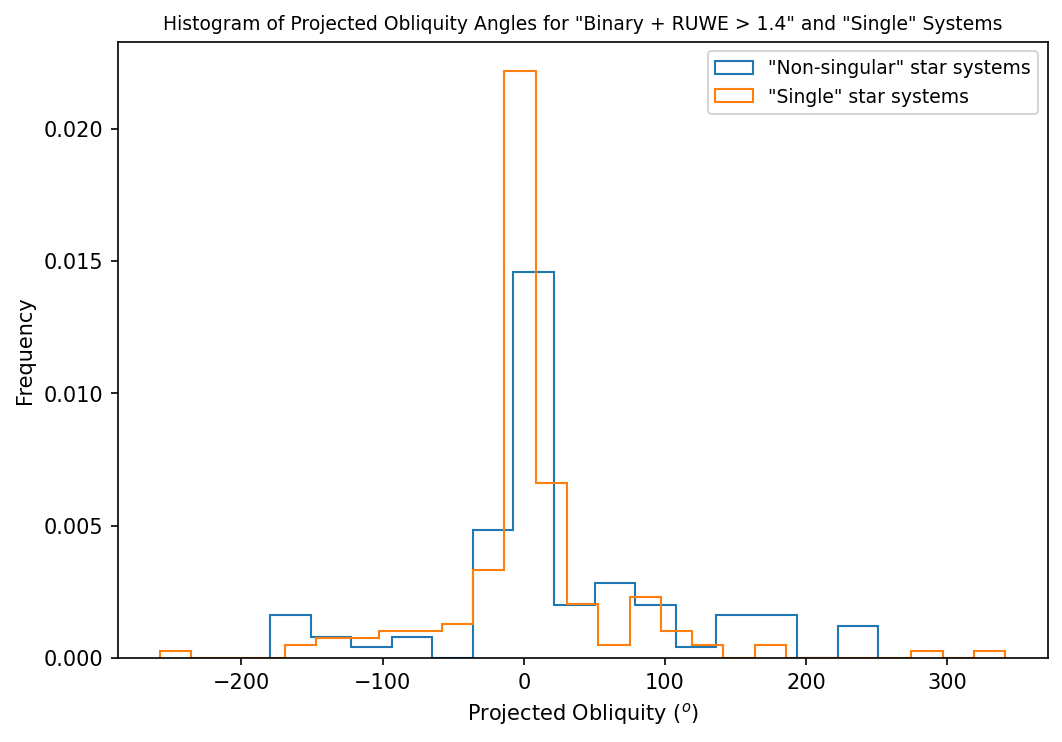

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [62]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.hist(binary_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.hist(single_sys_ruwe['pl_projobliq'], histtype='step', bins='auto', density=True);
plt.title('Histogram of Projected Obliquity Angles for "Binary + RUWE > 1.4" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('Frequency');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=1);

plt.savefig(output_loc + 'obliq_hist_Ruwe.png', transparent=True, dpi=300, format='png')

plt.show()

# Calculate the mean and standard deviation of the two populations as well
avg_sin_Ruwe = np.mean(single_sys_ruwe['pl_projobliq'])
std_sin_Ruwe = np.std(single_sys_ruwe['pl_projobliq'])
prmpt = r'\text{For single star systems, mean and standard deviation of projected obliquity angles are: }'
avg_txt = f'{avg_sin_Ruwe:.3f}'
std_txt = f'{std_sin_Ruwe:.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

avg_bin_Ruwe = np.mean(binary_sys_ruwe['pl_projobliq'])
std_bin_Ruwe = np.std(binary_sys_ruwe['pl_projobliq'])
prmpt = r'\text{For binary star systems, mean and standard deviation of projected obliquity angles are: }'
avg_txt = f'{avg_bin_Ruwe:.3f}'
std_txt = f'{std_bin_Ruwe:.3f}'
display(Math(prmpt + r'm = ' + avg_txt + r'\text{ and }\sigma = ' + std_txt));

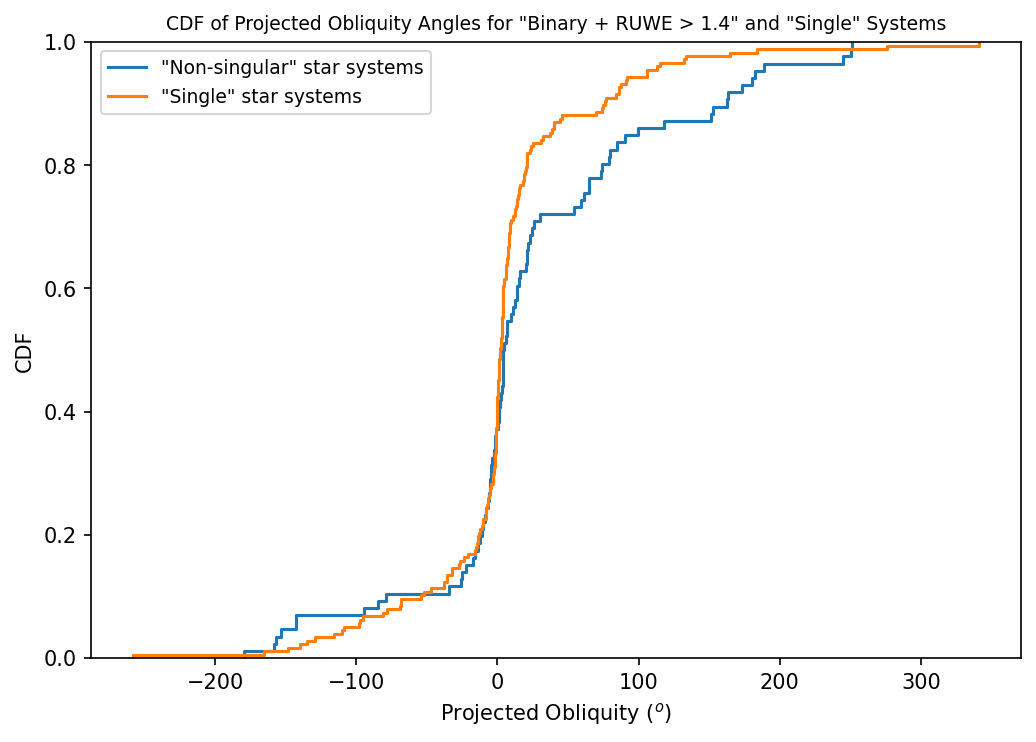

In [59]:
# Set the figure size
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

# Plot a histogram of the the two lists ('binary_sys' and 'single_sys')
plt.ecdf(binary_sys_ruwe['pl_projobliq']);
plt.ecdf(single_sys_ruwe['pl_projobliq']);
plt.title('CDF of Projected Obliquity Angles for "Binary + RUWE > 1.4" and "Single" Systems', fontsize=9);
plt.xlabel('Projected Obliquity $(^o)$');
plt.ylabel('CDF');
plt.legend(['"Non-singular" star systems', '"Single" star systems'], fontsize=9, loc=2);

plt.savefig(output_loc + 'obliq_ecdf_Ruwe.png', transparent=True, dpi=300, format='png')

plt.show()

Performing the actual hypothesis testing below.

In [65]:
# Calculating D and p-value for the 2-sample K-S test on the two datasets
# ('binary_sys' vs. 'single_sys')
ks_d_Ruwe, ks_p_Ruwe = stats.kstest(binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq'])
print(f'K-S D, p-value: {ks_d_Ruwe:0.4f} {ks_p_Ruwe:0.4}')

K-S D, p-value: 0.1631 0.07987


In [66]:
# Calculating the D and p-value for k-sample Anderson-Darling (A-D) test
#  on the two datasets ('binary_sys' vs. 'single_sys')
ad_Ruwe = stats.anderson_ksamp([binary_sys_ruwe['pl_projobliq'], single_sys_ruwe['pl_projobliq']], variant='midrank',
                          method=stats.PermutationMethod());
print(f'A-D statistics and p-value: {ad_Ruwe.statistic:0.4f} {ad_Ruwe.pvalue:0.4}')


A-D statistics and p-value: 2.5091 0.0301


In [ ]:
import pandas as pd

In [73]:
import dataframe_image as dfi

In [101]:
# Create a table to combine all results in
d = {"Non-RUWE": [avg_sin_nonRuwe, avg_bin_nonRuwe, std_sin_nonRuwe, std_bin_nonRuwe,
                  ks_d_nonRuwe, ks_p_nonRuwe, ad_nonRuwe.statistic, ad_nonRuwe.pvalue],
     "RUWE": [avg_sin_Ruwe, avg_bin_Ruwe, std_sin_Ruwe, std_bin_Ruwe,
              ks_d_Ruwe, ks_p_Ruwe, ad_Ruwe.statistic, ad_Ruwe.pvalue]}
df = pd.DataFrame(data=d, index=["Single mean", "Non-single mean", "Single std", "Non-Single std",
                                 "K-S D", "K-S p", "A-D D", "A-D p"])

df_styled = df.style.format("{:.3f}")
display(df_styled)
await dfi.export_async(df_styled, output_loc + 'hyp_testing_final_results.png', dpi=300, table_conversion='chrome')

,Non-RUWE,RUWE
Single mean,5.789,4.701
Non-single mean,23.002,23.240
Single std,64.680,63.337
Non-Single std,85.992,85.615
K-S D,0.148,0.163
K-S p,0.166,0.080
A-D D,1.478,2.509
A-D p,0.083,0.030


### 2. Correlation Testing

In this section, we examine the corrleation between the projected obliquity data and the RUWE data. We will use the Pearson correlation as well as the Spearman rank-order correlation test. The two tests are run on three different grouping of data as outlined below:

1. The first grouping looks at the correlation between projected obliquity and RUWE for the entire dataset (all 263 records).
2. For the second test, we will use the two groups (single and non-single systems) that we used for our 2nd hypthesis testing in section 1.2. We will run the correlation test between projected obliquity and RUWE bor both groups.
3. Lastly, we further filter the groups in (2) to include only systems whose RUWE <= 1.4.

For each of the 3 sets above, we also show a plot of projected obliquity vs. RUWE.

#### 2.1 Correlation Test on the entire dataset

For this first test, the entire dataset is used to determine the correlation between projected obliquity and RUWE.

In [85]:
# Combine the data into one list of all planets (star systems)
# with projected obliquities and RUWE
all_proj_obliq = table.vstack([single_sys_ruwe, binary_sys_ruwe])

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(all_proj_obliq['pl_projobliq'], all_proj_obliq['ruwe'])
print(f'\nThe Pearson r statistics for "all" star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(all_proj_obliq['pl_projobliq'], all_proj_obliq['ruwe'])
print(f'The Spearman rho statistics for "all" star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')



The Pearson r statistics for "all" star systems is 0.0285 with a p-value of 0.6450
The Spearman rho statistics for "all" star systems is 0.0795 with a p-value of 0.1987


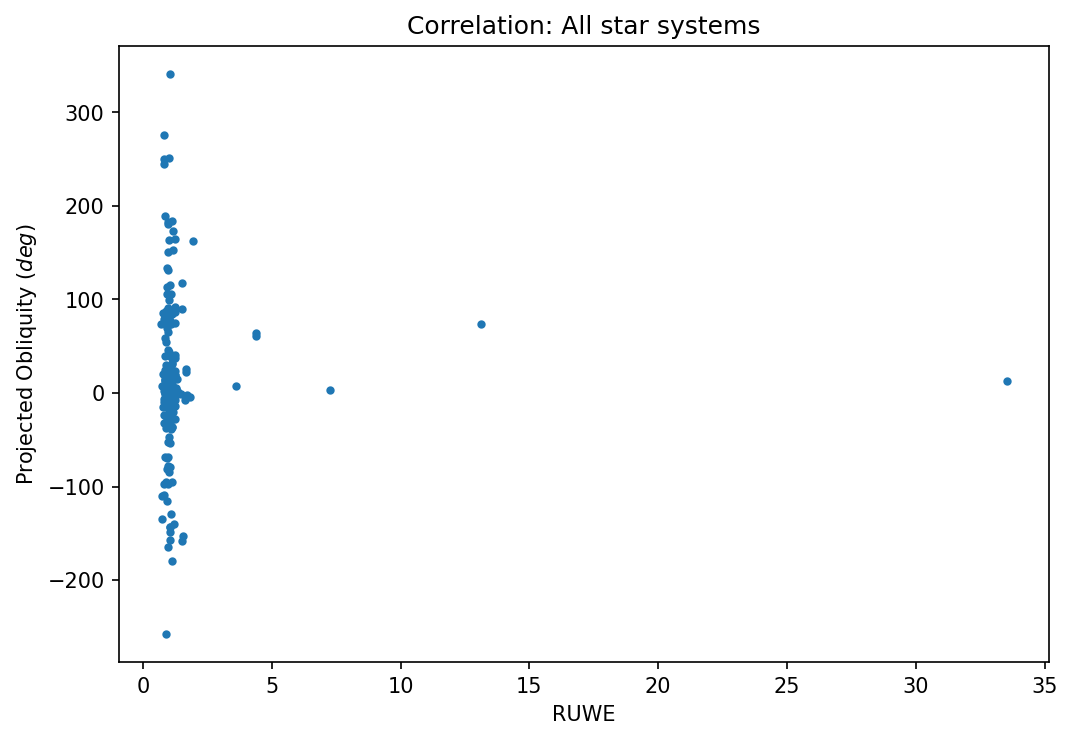

In [86]:
# Plot the Obliquity values vs. RUWE to see if there are any trends
fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.plot(all_proj_obliq['ruwe'], all_proj_obliq['pl_projobliq'], '.')
plt.title('Correlation: All star systems')
plt.xlabel('RUWE')
plt.ylabel(r'Projected Obliquity $(deg)$')

plt.savefig(output_loc + 'corr_all.png', transparent=True, dpi=300, format='png')

plt.show()


#### 2.2 Correlation Test on the groups from 1.2

The two groups of data for exoplanets in single systems with RUWE <= 1.4 and in non-single systems (as defined in section 1.2) are used to test the correlation between projected obliquity and RUWE. The test values for both datasets are calculated, and the two datasets are plotted side by side for comparison purposes.

In [87]:
# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for single star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'The Spearman rho statistics for single star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}\n')

# Calculating Pearson r statistic
pearson_r, pearson_p = stats.pearsonr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for "binary" star systems is {pearson_r:0.4f} with a p-value of {pearson_p:0.4f}')
# Calculating Spearman rho statistic
spearman_rho, spearman_p = stats.spearmanr(binary_sys_ruwe['pl_projobliq'], binary_sys_ruwe['ruwe'])
print(f'The Spearman rho statistics for "binary" star systems is {spearman_rho:0.4f} with a p-value of {spearman_p:0.4f}')



The Pearson r statistics for single star systems is 0.1585 with a p-value of 0.0351
The Spearman rho statistics for single star systems is 0.1871 with a p-value of 0.0127


The Pearson r statistics for "binary" star systems is 0.0051 with a p-value of 0.9629
The Spearman rho statistics for "binary" star systems is -0.1051 with a p-value of 0.3355


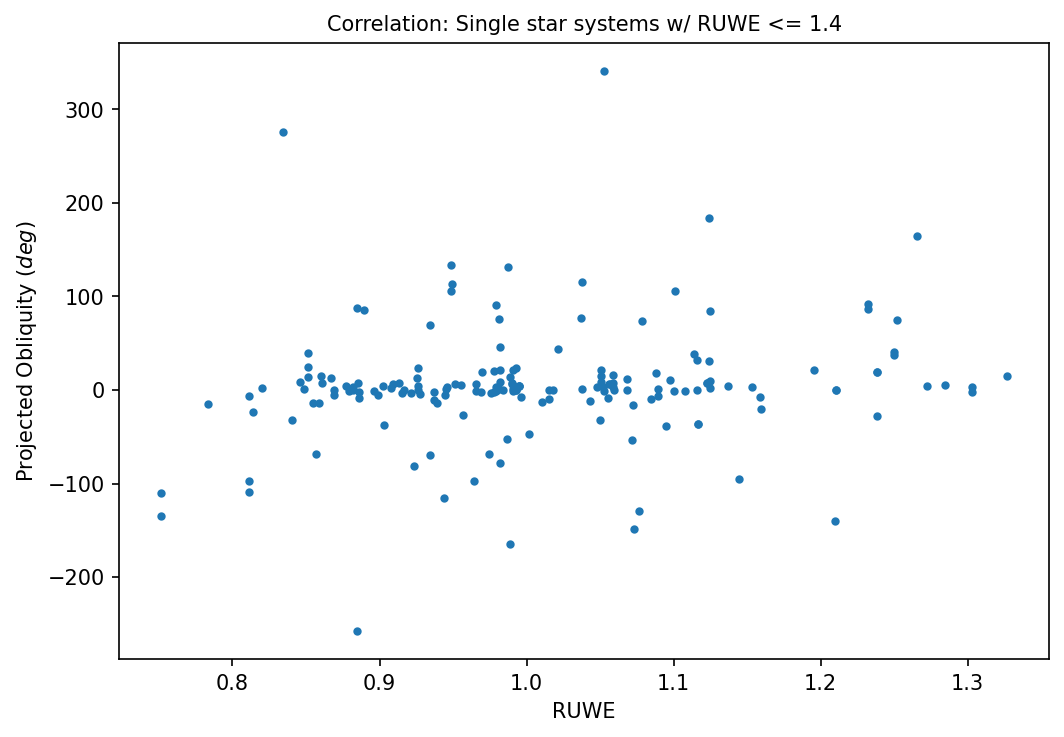

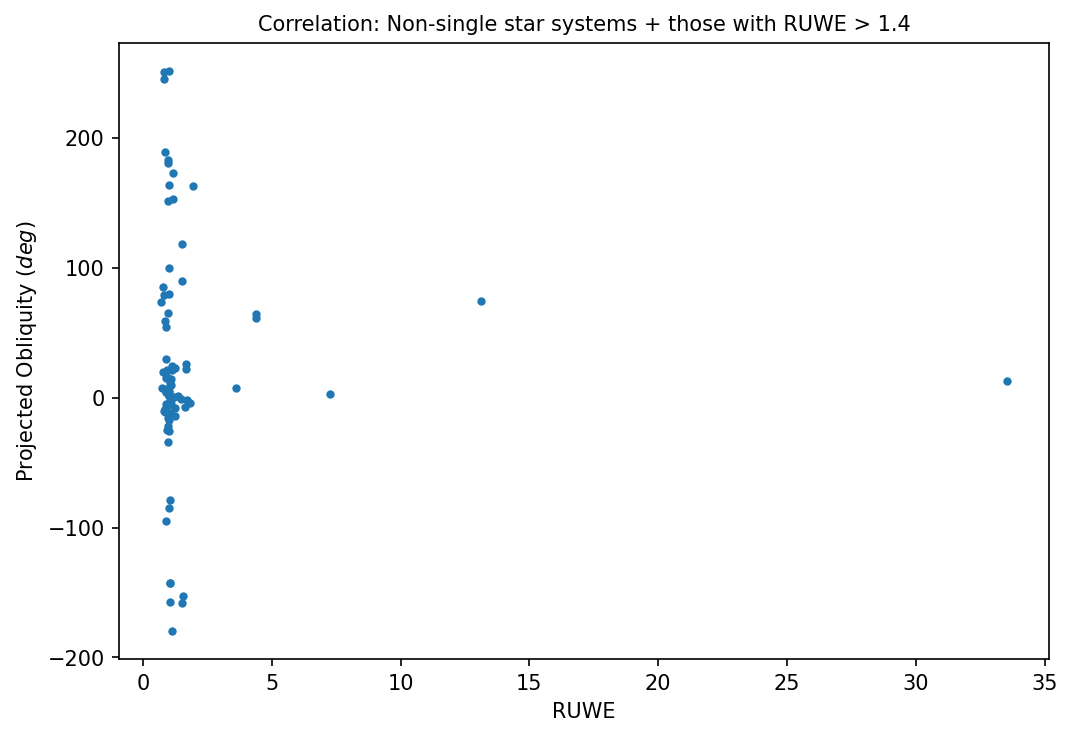

In [93]:
# Plot the Obliquity values vs. RUWE to see if there are any trends
fig_w = 8
fig_h = (fig_w) * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.plot(single_sys_ruwe['ruwe'], single_sys_ruwe['pl_projobliq'], '.')
plt.title('Correlation: Single star systems w/ RUWE <= 1.4', fontsize=10)
plt.xlabel('RUWE', fontsize=10)
plt.ylabel(r'Projected Obliquity $(deg)$', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig(output_loc + 'corr_sin.png', transparent=True, dpi=300, format='png')

plt.show()

fig_w = 8
fig_h = (fig_w) * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.plot(binary_sys_ruwe['ruwe'], binary_sys_ruwe['pl_projobliq'], '.')
plt.title('Correlation: Non-single star systems + those with RUWE > 1.4', fontsize=10)
plt.xlabel('RUWE', fontsize=10)
plt.ylabel(r'Projected Obliquity $(deg)$', fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig(output_loc + 'corr_bin.png', transparent=True, dpi=300, format='png')

plt.show()


#### 2.3 Correlation Test on single and non-single systems with RUWE <= 1.4

For this final correlation test, we used the datasets from section 1.2 but further filtered them to include only those with RUWE <= 1.4. The test values for both datasets are calculated, and the two datasets are plotted on the same plot for comparison purposes.

In [97]:
# List of planets in non-single star systems with RUWE numbers less than 1.4
bin_fit_ruwe = binary_sys_ruwe[binary_sys_ruwe['ruwe'] <= 1.4]

# Calculating Pearson r statistic for single stellar systems (whose RUWE is already <= 1.4)
sin_pearson_r, sin_pearson_p = stats.pearsonr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for single star systems is {sin_pearson_r:0.4f} with a p-value of {sin_pearson_p:0.4f}')
# Calculating Spearman rho statistic for single stellar systems (whose RUWE is already <= 1.4)
sin_spearman_rho, sin_spearman_p = stats.spearmanr(single_sys_ruwe['pl_projobliq'], single_sys_ruwe['ruwe'])
print(f'The Spearman rho statistics for single star systems is {sin_spearman_rho:0.4f} with a p-value of {sin_spearman_p:0.4f}\n')

# Calculating Pearson r statistic for non-single systems with RUSE <= 1.4
bin_pearson_r, bin_pearson_p = stats.pearsonr(bin_fit_ruwe['pl_projobliq'], bin_fit_ruwe['ruwe'])
print(f'\nThe Pearson r statistics for "binary" star systems with RUWE < 1.4 is {bin_pearson_r:0.4f} with a p-value of {bin_pearson_p:0.4f}')
# Calculating Spearman rho statistic for non-single systems with RUSE <= 1.4
bin_spearman_rho, bin_spearman_p = stats.spearmanr(bin_fit_ruwe['pl_projobliq'], bin_fit_ruwe['ruwe'])
print(f'The Spearman rho statistics for "binary" star systems with RUWE < 1.4 is {bin_spearman_rho:0.4f} with a p-value of {bin_spearman_p:0.4f}')



The Pearson r statistics for single star systems is 0.1585 with a p-value of 0.0351
The Spearman rho statistics for single star systems is 0.1871 with a p-value of 0.0127


The Pearson r statistics for "binary" star systems with RUWE < 1.4 is -0.2359 with a p-value of 0.0510
The Spearman rho statistics for "binary" star systems with RUWE < 1.4 is -0.2539 with a p-value of 0.0353


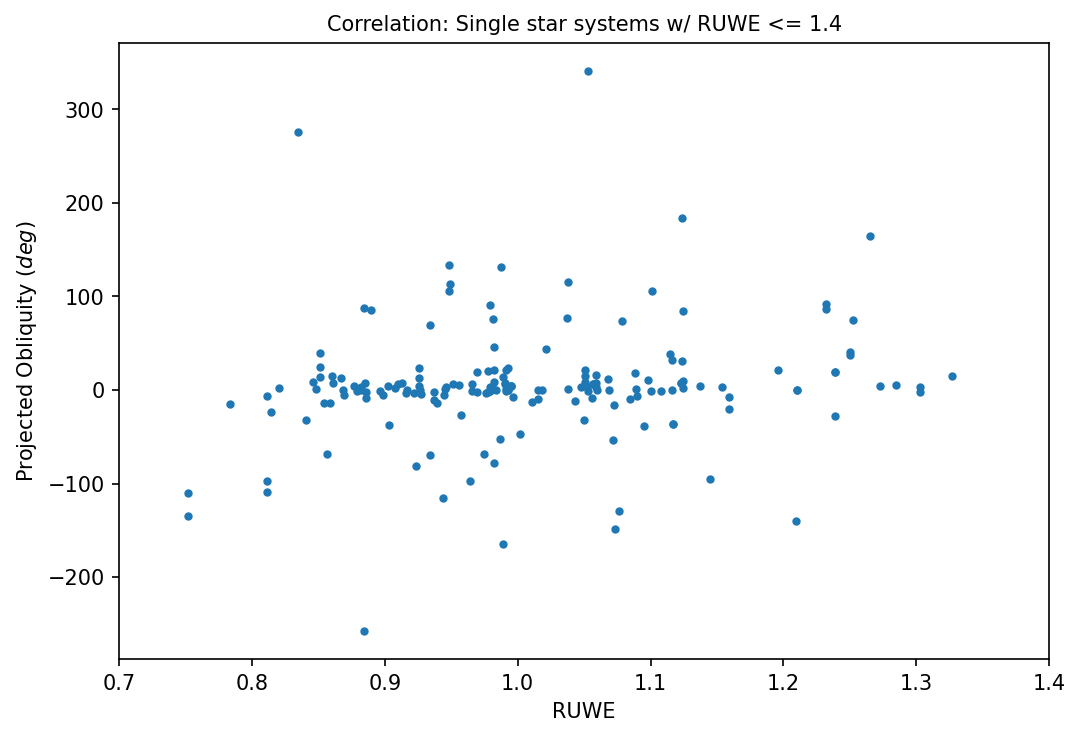

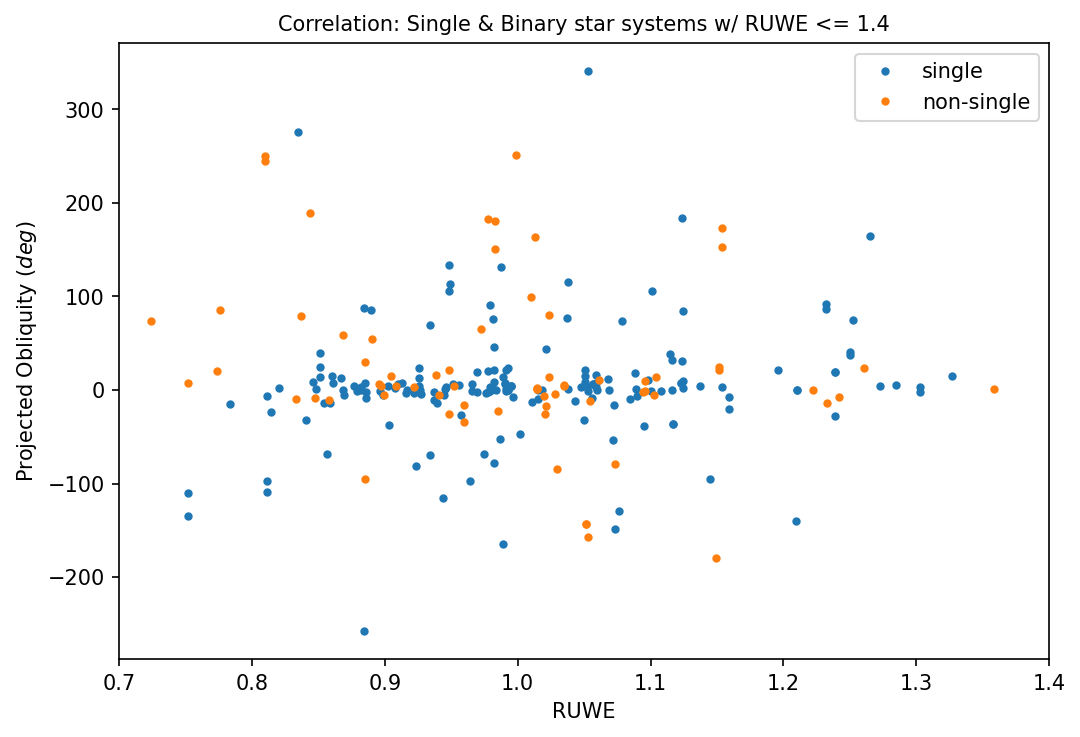

In [96]:
# Plot the Obliquity values vs. RUWE to see if there are any trends
fig_w = 8
fig_h = (fig_w) * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.plot(single_sys_ruwe['ruwe'], single_sys_ruwe['pl_projobliq'], '.')
plt.title('Correlation: Single star systems w/ RUWE <= 1.4', fontsize=10)
plt.xlabel('RUWE', fontsize=10)
plt.ylabel(r'Projected Obliquity $(deg)$', fontsize=10)
plt.xlim(0.7, 1.4)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig(output_loc + 'corr_sin_ruwe.png', transparent=True, dpi=300, format='png')

plt.show()

fig_w = 8
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h], dpi=150)

plt.plot(single_sys_ruwe['ruwe'], single_sys_ruwe['pl_projobliq'], '.', label='single')
plt.plot(bin_fit_ruwe['ruwe'], bin_fit_ruwe['pl_projobliq'], '.', label='non-single')
plt.title('Correlation: Single & Binary star systems w/ RUWE <= 1.4', fontsize=10)
plt.xlabel('RUWE', fontsize=10)
plt.ylabel(r'Projected Obliquity $(deg)$', fontsize=10)
plt.legend()
plt.xlim(0.7, 1.4)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig(output_loc + 'corr_sin_bin_ruwe.png', transparent=True, dpi=300, format='png')

plt.show()


In [99]:
# Print final results for correlation tests
d = {"Single System": [sin_pearson_r, sin_pearson_p, sin_spearman_rho, sin_spearman_p],
     "Non-Single System": [bin_pearson_r, bin_pearson_p, bin_spearman_rho, bin_spearman_p]}
df = pd.DataFrame(data=d, index=["Pearson r", "Pearson p", "Spearman rho", "Spearman p"])

df_styled = df.style.format("{:.3f}")
display(df_styled)
await dfi.export_async(df_styled, output_loc + 'corr_testing_final_results.png', dpi=300, table_conversion='chrome')

,Single System,Non-Single System
Pearson r,0.158,-0.236
Pearson p,0.035,0.051
Spearman rho,0.187,-0.254
Spearman p,0.013,0.035


### 3. Clustering (future work)

In this setion we will examine using different features (ruwe, projected obliquity, proper motion, planet's mass, star's mass...) to see if the data can be clustered into two single vs. non-single host system classes.

In [67]:
# Import clusterring related libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

 gaia_dr3_source_id discoverymethod sy_snum ...    ruwe        pm     label
------------------- --------------- ------- ... ---------- ---------- -----
3620030644476623616         Transit       1 ...  1.0180421  89.469215     0
3643098875168270592         Transit       1 ...  1.0594568   19.04588     0
3698307419878650240         Transit       1 ... 0.93699294  12.173809     0
3698307419878650240         Transit       1 ... 0.93699294  12.173809     0
3719927426253118848         Transit       1 ... 0.85676926  24.854477     0
3761497761876022400         Transit       1 ... 0.98203003  111.48808     0
3767805209112436736         Transit       1 ...  1.1534084    56.6357     0
3788394461991295488         Transit       1 ...  0.9654871  28.003206     0
3788394461991295488         Transit       1 ...  0.9654871  28.003206     0
3807826337147474176         Transit       1 ...  1.1161277   49.88264     0
                ...             ...     ... ...        ...        ...   ...
468373729456

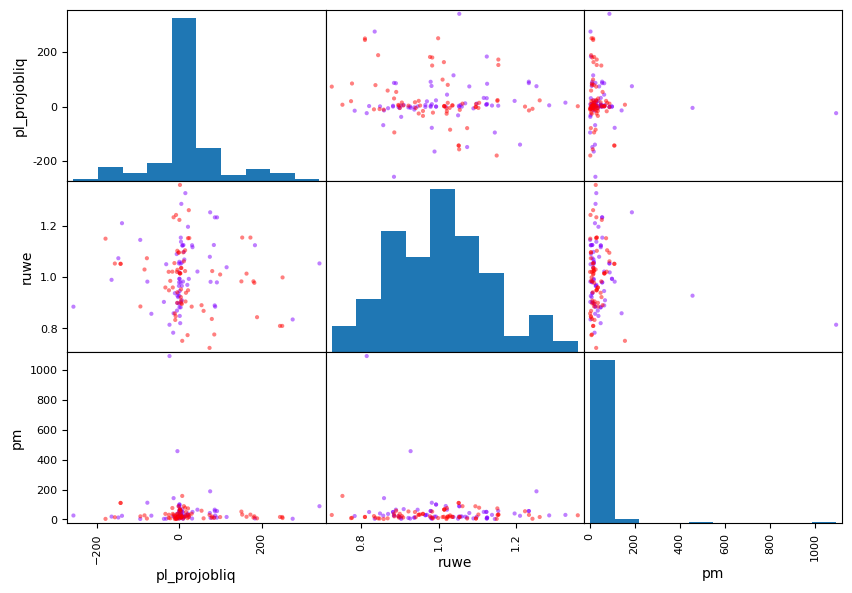

In [26]:
fig_w = 10
fig_h = fig_w * 6 / 9

# feature_list = ['sy_snum', 'pl_projobliq', 'ruwe']
feature_list = ['pl_projobliq', 'ruwe', 'pm']
# pd_dataset = all_proj_obliq[feature_list].to_pandas()

# Create a label column labeling data based on whether a system is single
# or non-single
if 'label' not in all_proj_obliq.colnames:
    label = np.ones_like(all_proj_obliq['sy_snum'])
    label[all_proj_obliq['sy_snum'] == 1] = 0
    all_proj_obliq.add_column(table.Column(label, name='label'))

# Include only data with RUWE < 1.4
train_data = all_proj_obliq[all_proj_obliq['ruwe'] < 1.4]

# Make the dataset equal sized between single and non-single systems
train_data = train_data[109:-1]


train_data.pprint()
print(f'\nNumber of data points with single star systems: {len(train_data[train_data['sy_snum'] == 1])}')
print(f'Number of data points with non-single star systems: {len(train_data[train_data['sy_snum'] > 1])}\n')

pd_dataset = train_data[feature_list].to_pandas()
pd.plotting.scatter_matrix(pd_dataset, c=train_data['label'], cmap='rainbow', figsize=[fig_w, fig_h]);

In [27]:
# Initialize the Scaler with default setting
scaler = StandardScaler()

# Train the Scaler with iris data
scaler.fit(pd_dataset)

# Whiten the iris data using the mean and variance calculated in the previous step
wht_dataset = pd.DataFrame(scaler.transform(pd_dataset), columns=['Projected Obliquity', 'RUWE', 'Proper Motion'])
# wht_dataset = pd_dataset


In [28]:
kmeans2 = KMeans(n_clusters=2)
kmeans2.fit(wht_dataset)
clusters2 = kmeans2.predict(wht_dataset)
print(clusters2)

[1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 0 1 1 0 1 1
 1 0 1 1 1 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 0 0 1
 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0
 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 0 0]


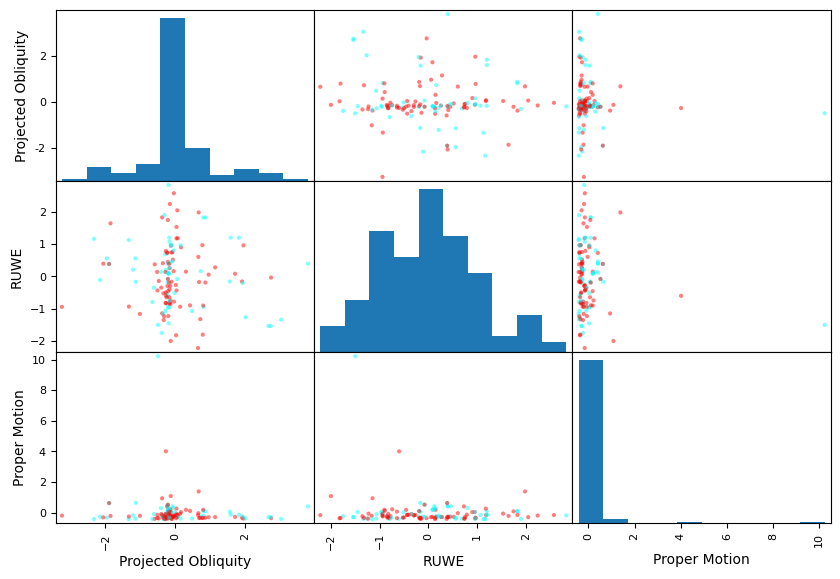

In [29]:
def scatter_plot(dataset, clusters, col_names=None, fig_w=10,
                 plt_color=np.array(['black', 'cyan', 'red', 'green', 'orange', 'blue', 'brown'])):

    # Set the figure size
    fig_h = fig_w * 6 / 9
    
    # Create a color list for the two clusters
    colors = np.empty_like(clusters, dtype=plt_color.dtype)
    
    # Go thru all the unique cluster labels, and...
    for i, cluster in enumerate(np.unique(clusters)):
        # ...assign colors from the plt_color list to each unique label, and...
        colors[clusters==cluster]  = plt_color[i]
    
        # ...group and sort iris data based on the cluster labels
        if i == 0:
            data_cluster = dataset[clusters==cluster]
        else:
            data_cluster = np.concat((data_cluster, dataset[clusters==cluster]))
        
    
    
    # Convert the grouped and sorted data back to pandas Data Frames and plot them
    data_cluster = pd.DataFrame(data_cluster, columns=col_names)
    pd.plotting.scatter_matrix(data_cluster, color=colors, figsize=[fig_w, fig_h]);

# scatter_plot(pd_dataset, clusters2, plt_color=np.array(['cyan', 'red', 'green']),
#                                                        col_names=['Number of Stars', 'Projected Obliquity', 'RUWE'])
scatter_plot(wht_dataset, clusters2, plt_color=np.array(['cyan', 'red', 'green']),
                                                       col_names=['Projected Obliquity', 'RUWE', 'Proper Motion'])

In [30]:
# Initialize the Principal Component Analysis class with 2 principal components
pca = PCA(n_components=2)

# Train the Principal Component Analysis class with the iris data
pca.fit(pd_dataset)
print(f'\nThe captured variances by the top 2 components are: {pca.explained_variance_ratio_}\n')

# Perform the projection on the iris data
pca_data = pd.DataFrame(pca.transform(pd_dataset), columns=['Component 1', 'Component 2'])
#print(np.mean(data_pca, axis=0), '\n\n', np.var(data_pca, axis=0))

# Run Kmeans clustering again, now on the whitened data
kmeans2 = KMeans(n_clusters=2)              # Setting number of clusters to 2
kmeans2.fit(pca_data)                       # Training the Kmeans algo
pca_clusters2 = kmeans2.predict(pca_data)   # Determining the clusters
print(pca_clusters2)



The captured variances by the top 2 components are: [0.5968095  0.40318963]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 4. Classification (future work)

In this setion we use the data features (projected obliquity, proper motion, planet's mass, star's mass...)  to see if the data can be classified into two different classes. Number of verified stars (> 1 or = 1) is used as the labels for training.

In [31]:
# Import classification related libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [32]:
print(wht_dataset)

     Projected Obliquity      RUWE  Proper Motion
0              -0.212557  0.119888       0.423083
1              -0.212557  0.449406      -0.264519
2              -0.244063 -0.524983      -0.331617
3              -0.340699 -0.524983      -0.331617
4              -1.013154 -1.163286      -0.207805
..                   ...       ...            ...
131            -0.165532 -0.753507      -0.327153
132            -0.306606  1.900104      -0.409400
133             1.821267  1.199413      -0.139526
134             1.586143  1.199413      -0.139526
135             1.562631 -0.159143       0.059173

[136 rows x 3 columns]


In [33]:
# Create a classifier instance of KNN with 5 neighbors
num_neigbor = 2
knn_clf05 = KNeighborsClassifier(n_neighbors=num_neigbor)

# Create a K-Fold splitter instance with randomizer turned on
kf_splits = 20
kf = KFold(n_splits=kf_splits, shuffle=True, random_state=12345)

labels05 = cross_val_predict(knn_clf05, wht_dataset, train_data['label'].data, cv=kf)
# train_data['label'].pprint()
# print(train_data['label'].data)
print('\n')
print(labels05)

acc_score05 = accuracy_score(train_data['label'].data, labels05, normalize=True)
print(f'\nAccuracy score: {acc_score05:0.2%}\n')




[0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1
 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1]

Accuracy score: 59.56%



In [34]:
# Create a classifier instance of KNN with 5 neighbors
rf_clf = RandomForestClassifier(n_estimators=100, criterion='entropy', min_samples_split=2)

# Create a K-Fold splitter instance with randomizer turned on
kf_splits = 20
kf = KFold(n_splits=kf_splits, shuffle=True, random_state=12345)

rf_labels = cross_val_predict(rf_clf, wht_dataset, train_data['label'].data, cv=kf)
print(rf_labels)
print(len(rf_labels), len(train_data['label']))

# Given the predicted results, compute the accuracy score
rf_acc_score = accuracy_score(train_data['label'].data, rf_labels, normalize=True)
print(f'\nAccuracy score: {rf_acc_score:0.2%}\n')


[0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 1 0 1
 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 1 1
 1 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 1 0 1 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1]
136 136

Accuracy score: 63.24%



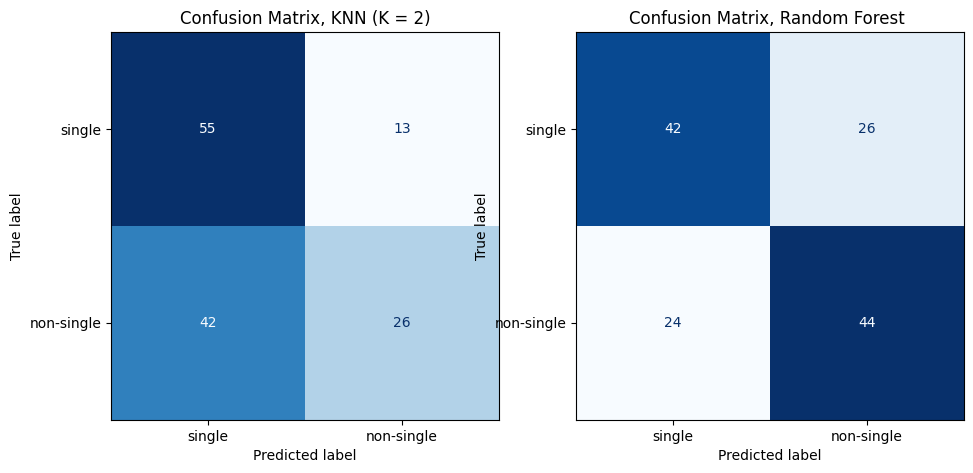

In [35]:
fig_w = 11
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h])

ax = plt.subplot(121)
ax.set_aspect('equal')
ConfusionMatrixDisplay.from_predictions(train_data['label'].data, labels05, display_labels=['single', 'non-single'],
                                        cmap='Blues', colorbar=False, ax=ax)
plt.title(f'Confusion Matrix, KNN (K = {num_neigbor})')

ax = plt.subplot(122)
ax.set_aspect('equal')
ConfusionMatrixDisplay.from_predictions(train_data['label'].data, rf_labels, display_labels=['single', 'non-single'],
                                        cmap='Blues', colorbar=False, ax=ax)
plt.title('Confusion Matrix, Random Forest ')

plt.show()


### Appendix
This section contains cells to provide numbers and plots for the presentation and/or report

In [36]:
# Plot normal and Rayleigh distributions
from scipy import stats

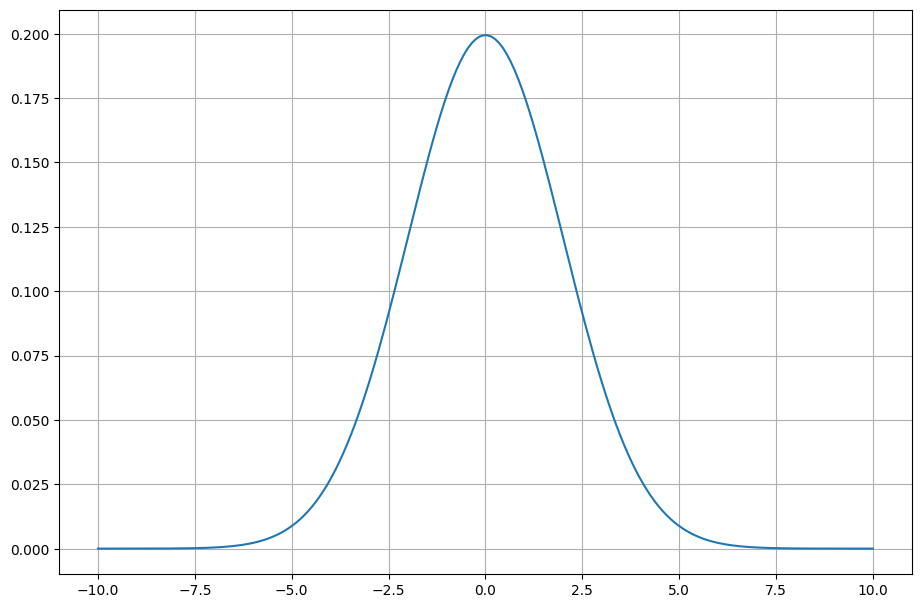

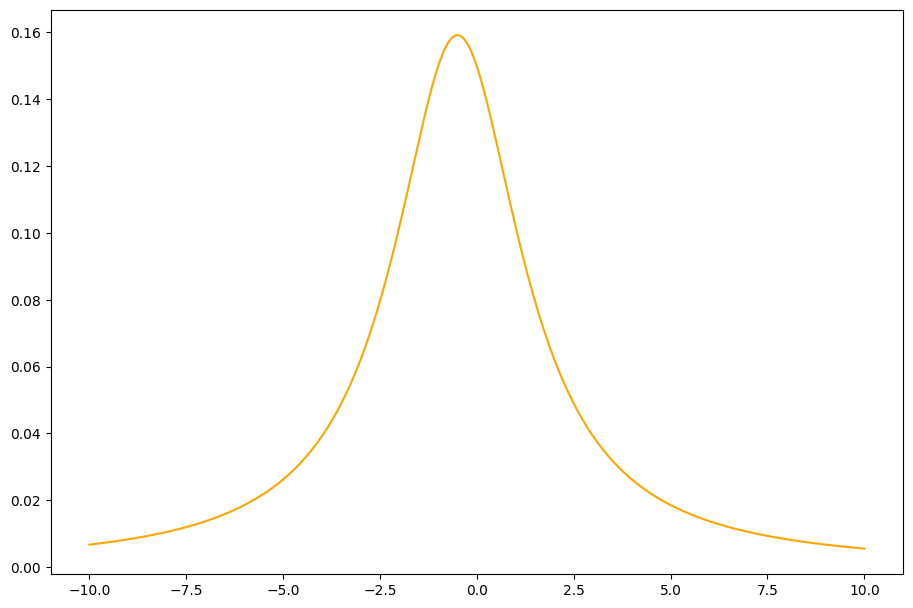

In [48]:
fig_w = 11
fig_h = fig_w * 6 / 9
plt.figure(figsize=[fig_w, fig_h])

x_min = -10
x_max = 10
x_stp = 0.1
x_num = (int)((x_max - x_min) / x_stp)
x_range = np.linspace(x_min, x_max, num=x_num)

# Plot a normal distribution with mean 10 and std 2
mu = 0
sigma = 2
y_norm = stats.norm.pdf(x_range, mu, sigma)
plt.plot(x_range, y_norm);
plt.grid()
plt.show()

plt.figure(figsize=[fig_w, fig_h])

y_ray = stats.cauchy.pdf(x_range, loc=-0.5, scale=2)
plt.plot(x_range, y_ray, 'orange');
plt.show()
